In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier, TabPFNRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score


# Load data
file_path = 'data_exploded_output.csv'
data_exploded = pd.read_csv(file_path)

In [2]:
data_exploded = data_exploded[data_exploded['phase_ids'] != 0]

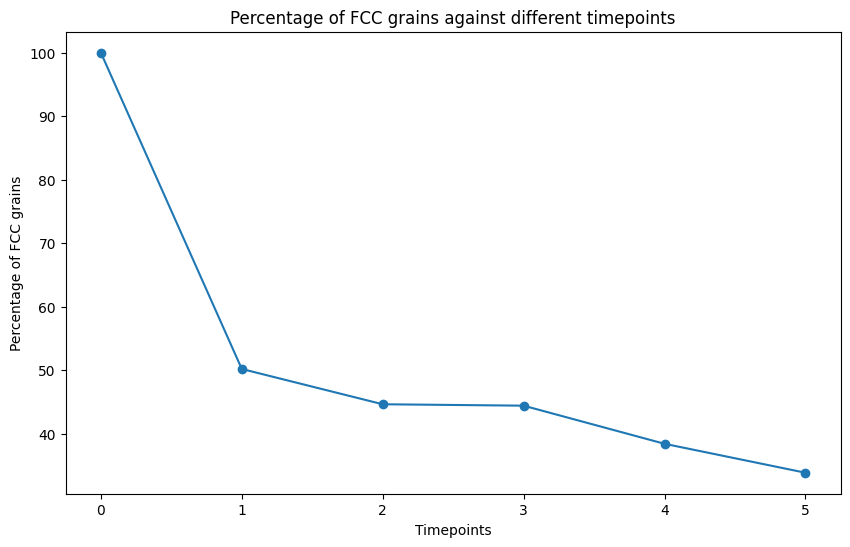

In [7]:
# Calculate the percentage of rows with 'phase_ids' equal to 2 for each timepoint
percentage_phase_2 = data_exploded[data_exploded['phase_ids'] == 2].groupby('timepoints').size() / data_exploded.groupby('timepoints').size() * 100

# Plot the percentage
percentage_phase_2.plot(kind='line', figsize=(10, 6), marker='o')
plt.xlabel('Timepoints')
plt.ylabel('Percentage of FCC grains')
plt.title('Percentage of FCC grains against different timepoints')
plt.show()

Model Training

In [22]:
X = data_exploded[['timepoints', 'grain_ids', 'grain_areas_pix',
       'grain_areas_um2', 'grain_strains', 'fraction']]

y = data_exploded['phase_ids']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

In [23]:
score = cross_val_score(TabPFNClassifier(), X, y, scoring='accuracy', cv=5, n_jobs=1, verbose=1)
score

array([0.70149254, 0.65981308, 0.7271028 , 0.77009346, 0.72523364])

In [24]:
# clf = TabPFNClassifier()
# clf.fit(X_train, y_train)

# # Predict probabilities
# # prediction_probabilities = clf.predict_proba(X_test)
# # print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

# # Predict labels
# predictions = clf.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, predictions))

In [26]:
y.value_counts()

phase_ids
2    1409
1    1267
Name: count, dtype: int64